<a href="https://colab.research.google.com/github/ldfha/RotemAI/blob/main/projects/pro13cnn/cnn12mobilenetv2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# MobileNet v2는 주로 대규모 이미지 데이터셋인 ImageNet 데이터베이스를 기반으로 학습된
# 사전 훈련 모델(pretrained model)을 사용한다.
# 주요 특징과 라벨 정보는 다음과 같다.
# 1000개의 클래스 : ImageNet 데이터셋의 1000가지 물체 카테고리(개, 고양이, 자동차, 과일 등)
# 사전 훈련된 모델 : 140만 개 이상의 이미지를 사용하여 학습되었다.

# 학습된 대형모델(백본)인 MobileNet v2로 cifa10 dataset을 분류하기
import tensorflow as tf
import matplotlib.pyplot as plt

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

x_train = x_train.astype('float32')/255.0
x_test = x_test.astype('float32')/255.0

NUM_CLASSES = 10
y_train = tf.keras.utils.to_categorical(y_train, NUM_CLASSES)
y_test = tf.keras.utils.to_categorical(y_test, NUM_CLASSES)

print('train data : ', x_train.shape) # (50000, 32, 32, 3)
print('test data : ', x_test.shape)   # (10000, 32, 32, 3)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step
train data :  (50000, 32, 32, 3)
test data :  (10000, 32, 32, 3)


In [ ]:
# MobileNet v2 모델 불러오기
mobilenet_model = tf.keras.applications.MobileNetV2(
    input_shape=(32, 32, 3),
    include_top=True,         # 기본 분류기 포함
    weights=None,             # 모델 구조만 불러오고 모든 가중치는 랜덤 처리
    classes=NUM_CLASSES       # cifar10의 클래스 수로 지정
)

print(mobilenet_model.summary())

Model: "mobilenetv2_1.00_32"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 16, 16,    │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 16, 16,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 16, 16,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 16, 16,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 16, 16,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 16, 16,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 16, 16,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 16, 16,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 16, 16,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 16, 16,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 16, 16,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 17, 17,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 8, 8, 96)  │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 8, 8, 96)  │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 8, 8, 96)  │          0 │ block_1_depthwis… │
│ (ReLU)              │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 8, 8, 24)  │      2,304 │ block_1_depthwis

 Total params: 2,270,794 (8.66 MB)

 Trainable params: 2,236,682 (8.53 MB)

 Non-trainable params: 34,112 (133.25 KB)

None


In [ ]:
mobilenet_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history = mobilenet_model.fit(x_train, y_train, batch_size=64, epochs=10, validation_split=0.2, verbose=2)

loss, acc = mobilenet_model.evaluate(x_test, y_test, verbose=0)
print(f'loss: {loss:.4f}, accuracy: {acc:.4f}')

Epoch 1/10
625/625 - 63s - 100ms/step - accuracy: 0.2837 - loss: 1.9694 - val_accuracy: 0.0997 - val_loss: 2.3265
Epoch 2/10
625/625 - 9s - 15ms/step - accuracy: 0.4117 - loss: 1.6219 - val_accuracy: 0.0952 - val_loss: 2.3409
Epoch 3/10
625/625 - 9s - 15ms/step - accuracy: 0.4613 - loss: 1.4910 - val_accuracy: 0.1016 - val_loss: 2.3655
Epoch 4/10
625/625 - 9s - 14ms/step - accuracy: 0.5003 - loss: 1.3936 - val_accuracy: 0.1016 - val_loss: 2.3667
Epoch 5/10
625/625 - 9s - 15ms/step - accuracy: 0.4415 - loss: 1.5750 - val_accuracy: 0.1014 - val_loss: 2.3506
Epoch 6/10
625/625 - 9s - 15ms/step - accuracy: 0.5289 - loss: 1.3168 - val_accuracy: 0.1262 - val_loss: 2.3520
Epoch 7/10
625/625 - 9s - 15ms/step - accuracy: 0.5535 - loss: 1.2774 - val_accuracy: 0.0982 - val_loss: 2.5554
Epoch 8/10
625/625 - 9s - 14ms/step - accuracy: 0.3790 - loss: 1.7346 - val_accuracy: 0.1995 - val_loss: 2.4164
Epoch 9/10
625/625 - 9s - 15ms/step - accuracy: 0.4455 - loss: 1.5417 - val_accuracy: 0.2777 - val_los

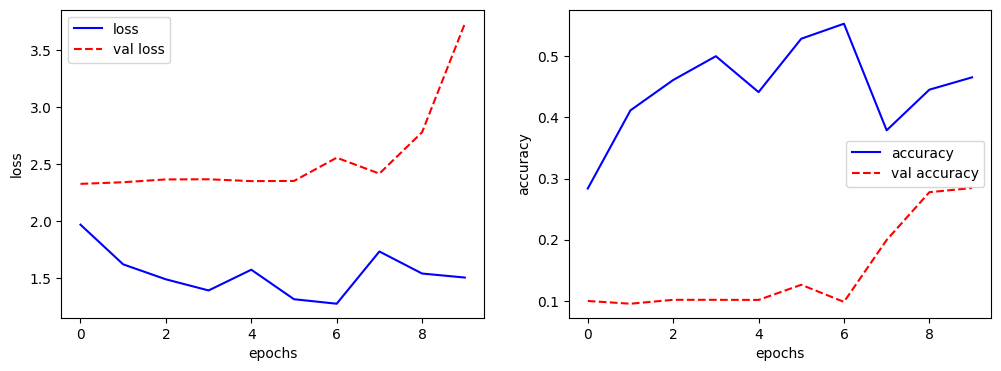

In [ ]:
# 성능 시각화
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], 'b-', label='loss')
plt.plot(history.history['val_loss'], 'r--', label='val loss')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], 'b-', label='accuracy')
plt.plot(history.history['val_accuracy'], 'r--', label='val accuracy')
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.legend()
plt.show()